## Ejercicio 2

Desarrolle un modelo de autoencoder que permita detectar transacciones realizadas con tarjetas de crédito fraudulentas.

Utilice el dataset **creditcard.csv** provisto en la carpeta de datos del Moodle o descárguelo desde el enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud. Este presenta transacciones que ocurrieron en dos días, donde se detectaron 492 fraudes de un total de 284,807 transacciones. Los datos están altamente desbalanceados, ya que la clase positiva (fraudes) representa menos del 0.2% de todas las transacciones.

In [1]:
FUENTES_DIR = '../Fuentes'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Data_Sets/p6/' # carpeta donde se encuentran los datasets
LOCAL_DIR = DATOS_DIR
import sys
sys.path.append(FUENTES_DIR)

In [2]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler

2025-10-31 09:41:58.258922: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-31 09:41:59.145040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-31 09:42:00.754730: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
nombre_archivo = DATOS_DIR + 'creditcard.csv'

df = pd.read_csv(nombre_archivo)

# Información básica
print("Shape del dataset:", df.shape)
print(df['Class'].value_counts())

Shape del dataset: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [6]:
# =====================
# SEPARAR FEATURES Y ETIQUETAS
# =====================
labels = df["Class"].values
data = df.drop(columns=["Class"]).values

# =====================
# NORMALIZACIÓN
# =====================
# Escalamos TODAS las features al rango [0, 1]
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# =====================
# DIVISIÓN TRAIN/TEST
# =====================
train_data, test_data, train_labels, test_labels = train_test_split(
    data_scaled, labels, test_size=0.2, random_state=42
)

# =====================
# SEPARAR DATOS NORMALES Y FRAUDULENTOS
# =====================
# Entrenamos solo con transacciones normales (Class == 0)
normal_train_data = train_data[train_labels == 0]
normal_test_data = test_data[test_labels == 0]
fraud_test_data = test_data[test_labels == 1]

print(f"Transacciones normales entrenamiento: {len(normal_train_data)}")
print(f"Fraudes en testeo: {len(fraud_test_data)}")

Transacciones normales entrenamiento: 227451
Fraudes en testeo: 98


In [ ]:
from tensorflow.keras import layers, regularizers

# Codificador mejorado
encoder = tf.keras.Sequential([
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu")],  # Espacio latente más grande que 8
    name='Encoder'
)

# Decodificador mejorado
decoder = tf.keras.Sequential([
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dense(140, activation="sigmoid")],  # Mantenemos sigmoid para salida normalizada
    name='Decoder'
)

# Modelo completo del autoencoder
inputs = tf.keras.Input(shape=(140,))
encoded = encoder(inputs)
decoded = decoder(encoded)

autoencoder = tf.keras.Model(
    inputs=inputs,
    outputs=decoded,
    name='ECG_Autoencoder'
)

# Compilación con optimizador ajustado
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='mse',
                  metrics=['mae'])


print(encoder.summary())
print(decoder.summary())
print(autoencoder.summary())


# AUTOENCODER

In [8]:
from tensorflow.keras import layers, regularizers

INPUT_DIM = normal_train_data.shape[1]  # ahora son 30 características

encoder = tf.keras.Sequential([
    layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu")  # espacio latente pequeño para forzar compresión
], name='Encoder')

decoder = tf.keras.Sequential([
    layers.Dense(8, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(16, activation="relu"),
    layers.Dense(INPUT_DIM, activation="sigmoid")  # salida normalizada
], name='Decoder')

inputs = tf.keras.Input(shape=(INPUT_DIM,))
encoded = encoder(inputs)
decoded = decoder(encoded)
autoencoder = tf.keras.Model(inputs, decoded, name='CreditCard_Autoencoder')

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

print(autoencoder.summary())

E0000 00:00:1761915182.405349    3671 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1761915182.413925    3671 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "CreditCard_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Sequential)            │ (None, 4)              │           732 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 30)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,458 (5.70 KB)

 Trainable params: 1,410 (5.51 KB)

 Non-trainable params: 48 (192.00 B)

None


# Entrenamiento

In [9]:
history = autoencoder.fit(
    normal_train_data, normal_train_data,
    epochs=50,
    batch_size=256,
    validation_data=(normal_test_data, normal_test_data),
    shuffle=True
)

Epoch 1/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0154 - mae: 0.0598 - val_loss: 0.0062 - val_mae: 0.0467
Epoch 2/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0018 - mae: 0.0273 - val_loss: 0.0026 - val_mae: 0.0338
Epoch 3/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0015 - mae: 0.0253 - val_loss: 0.0081 - val_mae: 0.0655
Epoch 4/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0014 - mae: 0.0242 - val_loss: 0.0050 - val_mae: 0.0515
Epoch 5/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0014 - mae: 0.0236 - val_loss: 0.0049 - val_mae: 0.0495
Epoch 6/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0014 - mae: 0.0232 - val_loss: 0.0038 - val_mae: 0.0371
Epoch 7/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0013 - mae: 0.0230 - val_loss: 0.0062 - val_mae: 0.0453
Epoch 8/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0013 - mae: 0.0227 - val_loss: 0.0018 - val_mae: 0.0277
Epoch 9/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

# Evaluacion

In [10]:
# Calculamos el error de reconstrucción para test normales y fraudes
reconstructions = autoencoder.predict(test_data)
reconstruction_errors = np.mean(np.square(reconstructions - test_data), axis=1)

# Definimos un umbral (threshold) a partir del error en los datos normales
threshold = np.percentile(reconstruction_errors[test_labels == 0], 95)
print("Umbral de detección:", threshold)

# Clasificación según error
predictions = (reconstruction_errors > threshold).astype(int)

# =====================
# MÉTRICAS
# =====================
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(test_labels, predictions))
print(classification_report(test_labels, predictions, digits=4))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 473us/step
Umbral de detección: 0.0032316796881050555
[[54020  2844]
 [   15    83]]
              precision    recall  f1-score   support

           0     0.9997    0.9500    0.9742     56864
           1     0.0284    0.8469    0.0549        98

    accuracy                         0.9498     56962
   macro avg     0.5140    0.8985    0.5145     56962
weighted avg     0.9981    0.9498    0.9726     56962



# Visualizacion

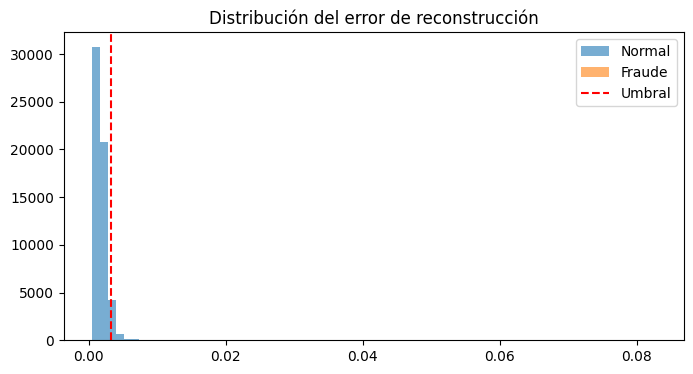

In [11]:
plt.figure(figsize=(8,4))
plt.hist(reconstruction_errors[test_labels == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(reconstruction_errors[test_labels == 1], bins=50, alpha=0.6, label="Fraude")
plt.axvline(threshold, color='red', linestyle='--', label='Umbral')
plt.legend()
plt.title("Distribución del error de reconstrucción")
plt.show()